# Import packages and datasets

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from simulator import simulate
import pandas as pd

In [2]:
infected_df = pd.read_csv("infected_timeseries.csv")
rewiring_df = pd.read_csv("rewiring_timeseries.csv")
degree_df = pd.read_csv("final_degree_histograms.csv")

infected_values = []
for i in range(0, 40):
    df = infected_df[infected_df["replicate_id"] == i]
    result = df["infected_fraction"].values
    infected_values.append(np.array(result))

rewiring_values = []
for i in range(0, 40):
    df = rewiring_df[rewiring_df["replicate_id"] == i]
    result = df["rewire_count"].values
    rewiring_values.append(np.array(result))

degree_values = []
for i in range(0, 40):
    df = degree_df[degree_df["replicate_id"] == i]
    result = df["count"].values
    degree_values.append(np.array(result))
    
infected_values = np.array(infected_values)
rewiring_values = np.array(rewiring_values)
degree_values = np.array(degree_values)


# split train and test
rng = np.random.default_rng(42)
train_index = rng.choice(np.arange(40), size =32, replace = False )

# mean of 32 train obs
obs_infected = np.mean(infected_values[train_index], axis = 0)
obs_rewiring = np.mean(rewiring_values[train_index], axis = 0)
obs_degree = np.mean(degree_values[train_index], axis = 0)

# mean of 8 test obs
test_index = np.setdiff1d(np.arange(len(infected_values)), train_index)
test_obs_infected = np.mean(infected_values[test_index], axis = 0)
test_obs_rewiring = np.mean(rewiring_values[test_index], axis = 0)
test_obs_degree = np.mean(degree_values[test_index], axis = 0)

print(obs_infected.shape)
print(obs_rewiring.shape)
print(obs_degree.shape)

print(infected_values[test_index].shape)
print(test_obs_infected.shape)
print(test_obs_rewiring.shape)
print(test_obs_degree.shape)

(201,)
(201,)
(31,)
(8, 201)
(201,)
(201,)
(31,)


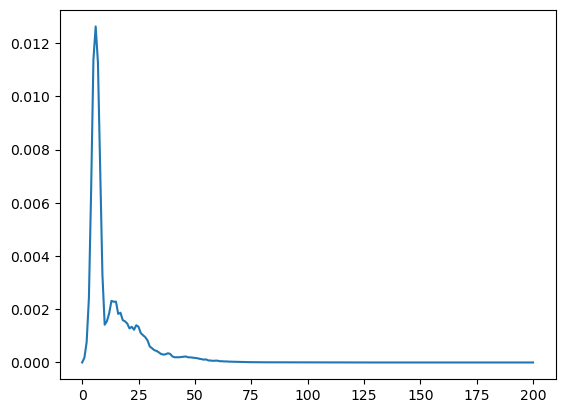

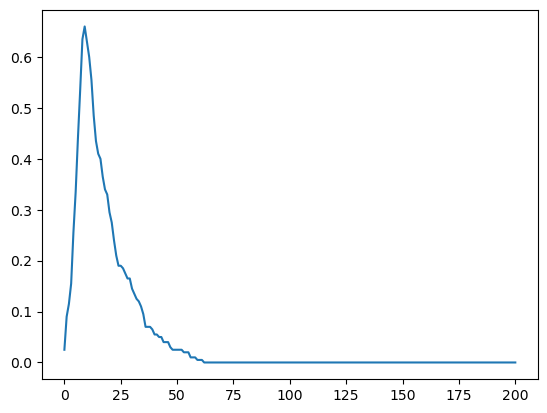

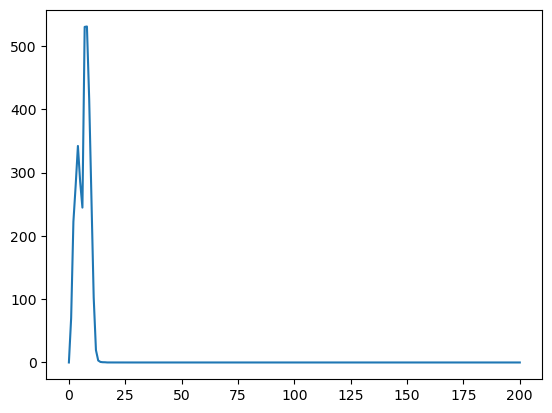

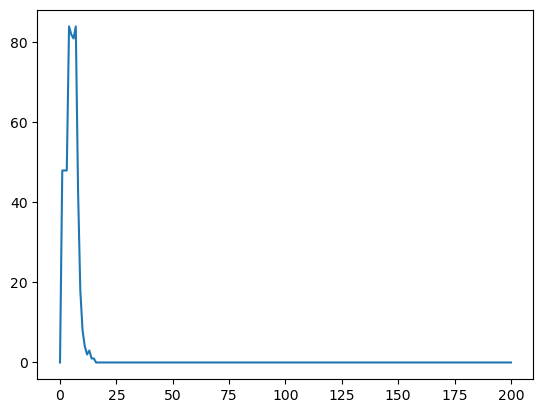

In [3]:
# var
plt.plot(range(201), np.var(np.array(infected_values).T, axis=1))

# compared with real y
plt.figure()
plt.plot(range(201),infected_values[35] )

plt.figure()
plt.plot(range(201), np.var(np.array(rewiring_values).T, axis=1))

plt.figure()
plt.plot(range(201),rewiring_values[35] )

<Figure size 640x480 with 0 Axes>

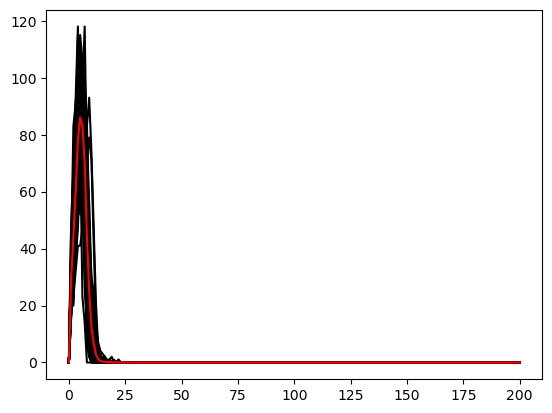

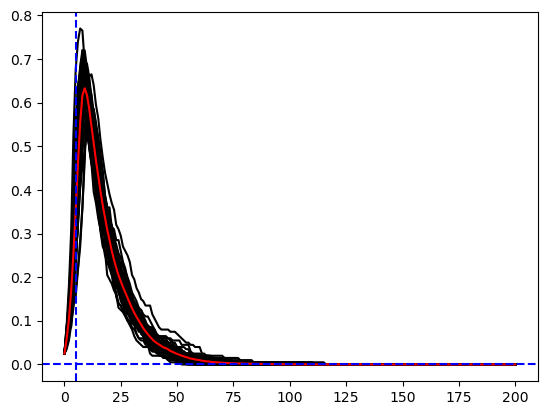

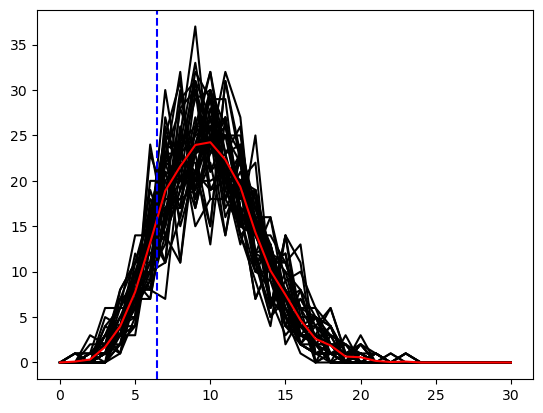

<Figure size 640x480 with 0 Axes>

In [4]:
# check mean of obs

for i in range(0, 40):
    plt.plot(range(201),rewiring_values[i], color= 'black')
plt.plot(range(201), np.mean(np.array(rewiring_values).T, axis = 1), color='red')

plt.figure()
for i in range(0, 40):
    plt.plot(range(201),infected_values[i], color = 'black')
plt.plot(range(201), np.mean(np.array(infected_values).T, axis = 1), color= 'red')
plt.axvline(x = 5,   linestyle = '--', color = 'blue')
plt.axhline(y = 0,   linestyle = '--', color = 'blue')

plt.figure()
for i in range(0, 40):
    plt.plot(range(31), degree_values[i], color = 'black')
plt.plot(range(31), np.mean(np.array(degree_values).T, axis = 1), color = 'red')
plt.axvline(x = np.mean(np.mean(np.array(degree_values).T, axis = 1)),   linestyle = '--', color = 'blue')

plt.figure()

# sim_data

In [5]:
beta_list = []
gamma_list = []
rho_list = []
sim_infected = []
sim_rewiring = []
sim_degree = []

N_sim = 20_000

for _ in range(N_sim):
    # generate prior
    beta_prior = rng.uniform(0.05, 0.5)
    gamma_prior = rng.uniform(0.02, 0.2)
    rho_prior = rng.uniform(0, 0.8)
    
    beta_list.append(beta_prior)
    gamma_list.append(gamma_prior)
    rho_list.append(rho_prior)
    
    # sim_data
    infected, rewires, degrees = simulate(beta = beta_prior, gamma = gamma_prior, rho = rho_prior, rng = rng)
    
    sim_infected.append(infected)
    sim_rewiring.append(rewires)
    sim_degree.append(degrees)

beta_list = np.array(beta_list)
gamma_list = np.array(gamma_list)
rho_list = np.array(rho_list)
sim_infected = np.array(sim_infected)
sim_rewiring = np.array(sim_rewiring)
sim_degree = np.array(sim_degree)

# Summary statistics

### 1. choose a set of summary statistics (using 5% acceptance, norm distance function)
evaluation metric:  
generate 50 samples from posterior parameters list.  
using these parameters to generate path (50 paths).  
compute squared norm/norm of summary statistics between each of 50 path and test path.  
compute avg, smaller, better

In [6]:
def check_all_zero_after_first_zero(infected_data):
    all_valid = True
    for idx, path in enumerate(infected_data):
        first_zero_idx = np.argmax(path < 1e-6)
        
        if first_zero_idx == 0 and path[0] > 1e-6:
            continue

        after_zero = path[first_zero_idx:]
        still_infected = np.sum(after_zero > 1e-6)
        
        if still_infected > 0:
            print(f"no")
            all_valid = False
    
    return all_valid

check_all_zero_after_first_zero(np.array(infected_values))

True

In [7]:
# normalization

peak_infected2 = np.max(sim_infected, axis = 1)
time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
total_Infected2 = np.sum(sim_infected, axis=1)                            
initial_growth2 = sim_infected.T[1]/sim_infected.T[0]
initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
duration2 = np.sum(sim_infected > 1e-6, axis = 1)
time_from_peak_to_end2 = duration2 - time_to_peak_infected2
       
total_rewire2 = np.sum(sim_rewiring, axis = 1)
peak_rewire2 = np.max(sim_rewiring, axis = 1)
time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

cov = np.mean(( sim_infected- np.mean(sim_infected, axis=1, keepdims=True)) * (sim_rewiring - np.mean(sim_rewiring, axis = 1,keepdims=True)), axis=1)
denom = sim_infected.std(axis=1) * sim_rewiring.std(axis=1)
correlation2 = np.zeros_like(denom)
valid = denom > 0
correlation2[valid] = cov[valid] / denom[valid]

mean_final_degree2 = np.mean(sim_degree, axis =1)
var_final_degree2 = np.var(sim_degree, axis = 1)

ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)






peak_infected_std = np.std(peak_infected2)
time_to_peak_infected_std = np.std(time_to_peak_infected2)
total_Infected_std = np.std(total_Infected2)                            
initial_growth_std = np.std(initial_growth2)
initial_slope_std = np.std(initial_slope2)
duration_std = np.std(duration2)
       
total_rewire_std = np.std(total_rewire2)
peak_rewire_std = np.std(peak_rewire2)
time_to_peak_rewire_std = np.std(time_to_peak_rewire2)
correlation_std = np.std(correlation2)

mean_final_degree_std = np.std(mean_final_degree2)
var_final_degree_std = np.std(var_final_degree2)

ratio_std = np.std(ratio2)
width_at_half_peak_std = np.std(width_at_half_peak2)
time_from_peak_to_end_std = np.std(time_from_peak_to_end2)




peak_infected_mean = np.mean(peak_infected2)
time_to_peak_infected_mean = np.mean(time_to_peak_infected2)
total_Infected_mean = np.mean(total_Infected2)                            
initial_growth_mean = np.mean(initial_growth2)
initial_slope_mean = np.mean(initial_slope2)
duration_mean = np.mean(duration2)
       
total_rewire_mean = np.mean(total_rewire2)
peak_rewire_mean = np.mean(peak_rewire2)
time_to_peak_rewire_mean = np.mean(time_to_peak_rewire2)
correlation_mean = np.mean(correlation2)

mean_final_degree_mean = np.mean(mean_final_degree2)
var_final_degree_mean = np.mean(var_final_degree2)

ratio_mean = np.mean(ratio2)
width_at_half_peak_mean = np.mean(width_at_half_peak2)
time_from_peak_to_end_mean = np.mean(time_from_peak_to_end2)

In [8]:
def accept_indices(distance, acceptance_rate):     
    eps = np.quantile(distance, acceptance_rate)
    indices = np.where(distance <= eps)[0]
    
    beta_accepted = beta_list[indices]
    gamma_accepted = gamma_list[indices]
    rho_accepted = rho_list[indices]
    return indices, beta_accepted, gamma_accepted, rho_accepted

def test_on_summary(accepted_indices, s):
    posterior_test_indices = rng.choice(accepted_indices, size = s, replace = False)

    beta_test_posterior = beta_list[posterior_test_indices]
    gamma_test_posterior = gamma_list[posterior_test_indices]
    rho_test_posterior = rho_list[posterior_test_indices]

    posterior_test_infected = []
    posterior_test_rewiring = []
    posterior_test_degree = []

    for i in range(s):
        beta_posterior = beta_test_posterior[i]
        gamma_posterior = gamma_test_posterior[i]
        rho_posterior = rho_test_posterior[i]
        
        infected, rewires, degrees = simulate(beta = beta_posterior, gamma = gamma_posterior, rho = rho_posterior, rng = rng)
        
        posterior_test_infected.append(infected)
        posterior_test_rewiring.append(rewires)
        posterior_test_degree.append(degrees)

    posterior_test_infected = np.array(posterior_test_infected)
    posterior_test_rewiring = np.array(posterior_test_rewiring)
    posterior_test_degree = np.array(posterior_test_degree)

    return posterior_test_infected, posterior_test_rewiring, posterior_test_degree




def plot_beta_across_summary(posterior):
    for i in range(len(posterior)):
        counts, bins, patches = plt.hist(
            posterior[i], density=True, bins=50,
            alpha=0.6, label=f"set {i+1}"
        )
        color = patches[0].get_facecolor()
        plt.axvline(
            x=np.mean(posterior[i]),
            linestyle='--',
            color=color,
            label=f'set {i+1} posterior mean'
        )

    x_axis_beta = np.linspace(0.05, 0.5, 100)
    y_axis_beta = np.ones(100) * (1/0.45)
    plt.plot(x_axis_beta, y_axis_beta)
    plt.axvline(x=0.55/2, linestyle='--', label='prior mean', color='black')
    plt.legend()


def plot_gamma_across_summary(posterior):
    for i in range(len(posterior)):
        counts, bins, patches = plt.hist(
            posterior[i], density=True, bins=50,
            alpha=0.6, label=f"set {i+1}"
        )
        color = patches[0].get_facecolor()
        plt.axvline(
            x=np.mean(posterior[i]),
            linestyle='--',
            color=color,
            label=f'set {i+1} posterior mean'
        )

    x_axis_gamma = np.linspace(0.02, 0.2, 100)
    y_axis_gamma = np.ones(100) * (1/0.18)
    plt.plot(x_axis_gamma, y_axis_gamma)
    plt.axvline(x=0.22/2, linestyle='--', label='prior mean', color='black')
    plt.legend()


def plot_rho_across_summary(posterior):
    for i in range(len(posterior)):
        counts, bins, patches = plt.hist(
            posterior[i], density=True, bins=50,
            alpha=0.6, label=f"set {i+1}"
        )
        color = patches[0].get_facecolor()
        plt.axvline(
            x=np.mean(posterior[i]),
            linestyle='--',
            color=color,
            label=f'set {i+1} posterior mean'
        )

    x_axis_rho = np.linspace(0, 0.8, 100)
    y_axis_rho = np.ones(100) * (1/0.8)
    plt.plot(x_axis_rho, y_axis_rho)
    plt.axvline(x=0.8/2, linestyle='--', label='prior mean', color='black')
    plt.legend()


In [9]:
acceptance_rate = 0.01

Set 1

In [10]:
def full_set_summary_obs(obs_infected, obs_rewiring, obs_degree):       # 13
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_growth = obs_infected[1]/obs_infected[0]
    initial_slope = obs_infected[5]-obs_infected[0]

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    
    # normalization
    peak_infected_norm = (peak_infected - peak_infected_mean) /peak_infected_std
    time_to_peak_infected_norm = (time_to_peak_infected - time_to_peak_infected_mean)/ time_to_peak_infected_std
    total_Infected_norm = (total_Infected - total_Infected_mean) / total_Infected_std
    initial_growth_norm = (initial_growth - initial_growth_mean) / initial_growth_std
    initial_slope_norm = (initial_slope - initial_slope_mean)/ initial_slope_std
        
    total_rewire_norm = (total_rewire - total_rewire_mean) / total_rewire_std
    peak_rewire_norm = (peak_rewire - peak_rewire_mean) / peak_rewire_std
    time_to_peak_rewire_norm =  (time_to_peak_rewire - time_to_peak_rewire_mean) / time_to_peak_rewire_std
    mean_final_degree_norm = (mean_final_degree -mean_final_degree_mean)  / mean_final_degree_std
    var_final_degree_norm = (var_final_degree - var_final_degree_mean) / var_final_degree_std
    ratio_norm  = (ratio - ratio_mean) / ratio_std
    
    width_at_half_peak_norm = ( width_at_half_peak - width_at_half_peak_mean) / width_at_half_peak_std 
    duration_norm = (duration - duration_mean) / duration_std
    
    return peak_infected_norm, time_to_peak_infected_norm, total_Infected_norm, initial_growth_norm, initial_slope_norm, total_rewire_norm, peak_rewire_norm, time_to_peak_rewire_norm, mean_final_degree_norm, var_final_degree_norm, ratio_norm, width_at_half_peak_norm, duration_norm



def full_set_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_growth2 = sim_infected.T[1]/sim_infected.T[0]
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis = 1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    
    peak_infected_norm2 = (peak_infected2 - peak_infected_mean) /peak_infected_std
    time_to_peak_infected_norm2 = (time_to_peak_infected2 - time_to_peak_infected_mean)/ time_to_peak_infected_std
    total_Infected_norm2 = (total_Infected2 - total_Infected_mean) / total_Infected_std
    initial_growth_norm2 = (initial_growth2 - initial_growth_mean) / initial_growth_std
    initial_slope_norm2 = (initial_slope2 - initial_slope_mean)/ initial_slope_std
        
    total_rewire_norm2 = (total_rewire2 - total_rewire_mean) / total_rewire_std
    peak_rewire_norm2 = (peak_rewire2 - peak_rewire_mean) / peak_rewire_std
    time_to_peak_rewire_norm2 =  (time_to_peak_rewire2 - time_to_peak_rewire_mean) / time_to_peak_rewire_std
    mean_final_degree_norm2 = (mean_final_degree2 -mean_final_degree_mean)  / mean_final_degree_std
    var_final_degree_norm2 = (var_final_degree2 - var_final_degree_mean) / var_final_degree_std
    ratio_norm2  = (ratio2 - ratio_mean) / ratio_std
    
    width_at_half_peak_norm2 = ( width_at_half_peak2 - width_at_half_peak_mean) / width_at_half_peak_std 
    duration_norm2 = (duration2 - duration_mean) / duration_std
    
    return peak_infected_norm2, time_to_peak_infected_norm2, total_Infected_norm2, initial_growth_norm2, initial_slope_norm2, total_rewire_norm2, peak_rewire_norm2, time_to_peak_rewire_norm2, mean_final_degree_norm2, var_final_degree_norm2, ratio_norm2, width_at_half_peak_norm2,  duration_norm2


In [11]:
summary_test1_train = full_set_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test1_sim = full_set_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test1_test = full_set_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test1_sim = np.array(summary_test1_sim).T
summary_test1_train = np.array(summary_test1_train)
summary_test1_test = np.array(summary_test1_test)


distance = np.linalg.norm(summary_test1_train - summary_test1_sim, axis = 1)      
                                                 
indices_test1_5, beta_test1_5, gamma_test1_5, rho_test1_5  = accept_indices(distance, acceptance_rate)

posterior_test1_infected, posterior_test1_rewiring, posterior_test1_degree = test_on_summary(indices_test1_5, 50)

summary_test1_post= full_set_summary_sim(posterior_test1_infected, posterior_test1_rewiring, posterior_test1_degree)
summary_test1_post = np.array(summary_test1_post).T


error = np.mean(np.linalg.norm(summary_test1_test - summary_test1_post, axis = 1)**2  )
print(error)
print(np.std(beta_test1_5))
print(np.std(gamma_test1_5))
print(np.std(rho_test1_5))

3.187634856622155
0.038176134373175206
0.017894387536454504
0.08306982855019435


Set 2

In [12]:
def set_2_summary_obs(obs_infected, obs_rewiring, obs_degree):      
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_growth = obs_infected[1]/obs_infected[0]
    initial_slope = obs_infected[5]-obs_infected[0]

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    
    # normalization
    peak_infected_norm = (peak_infected - peak_infected_mean) /peak_infected_std
    time_to_peak_infected_norm = (time_to_peak_infected - time_to_peak_infected_mean)/ time_to_peak_infected_std
    total_Infected_norm = (total_Infected - total_Infected_mean) / total_Infected_std
    initial_growth_norm = (initial_growth - initial_growth_mean) / initial_growth_std
    initial_slope_norm = (initial_slope - initial_slope_mean)/ initial_slope_std
        
    total_rewire_norm = (total_rewire - total_rewire_mean) / total_rewire_std
    peak_rewire_norm = (peak_rewire - peak_rewire_mean) / peak_rewire_std
    time_to_peak_rewire_norm =  (time_to_peak_rewire - time_to_peak_rewire_mean) / time_to_peak_rewire_std
    mean_final_degree_norm = (mean_final_degree -mean_final_degree_mean)  / mean_final_degree_std
    var_final_degree_norm = (var_final_degree - var_final_degree_mean) / var_final_degree_std
    ratio_norm  = (ratio - ratio_mean) / ratio_std
    
    width_at_half_peak_norm = ( width_at_half_peak - width_at_half_peak_mean) / width_at_half_peak_std 
    duration_norm = (duration - duration_mean) / duration_std
    
    return peak_infected_norm, total_Infected_norm, initial_slope_norm, total_rewire_norm, peak_rewire_norm, mean_final_degree_norm, ratio_norm, width_at_half_peak_norm, duration_norm



def set_2_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_growth2 = sim_infected.T[1]/sim_infected.T[0]
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis = 1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    
    peak_infected_norm2 = (peak_infected2 - peak_infected_mean) /peak_infected_std
    time_to_peak_infected_norm2 = (time_to_peak_infected2 - time_to_peak_infected_mean)/ time_to_peak_infected_std
    total_Infected_norm2 = (total_Infected2 - total_Infected_mean) / total_Infected_std
    initial_growth_norm2 = (initial_growth2 - initial_growth_mean) / initial_growth_std
    initial_slope_norm2 = (initial_slope2 - initial_slope_mean)/ initial_slope_std
        
    total_rewire_norm2 = (total_rewire2 - total_rewire_mean) / total_rewire_std
    peak_rewire_norm2 = (peak_rewire2 - peak_rewire_mean) / peak_rewire_std
    time_to_peak_rewire_norm2 =  (time_to_peak_rewire2 - time_to_peak_rewire_mean) / time_to_peak_rewire_std
    mean_final_degree_norm2 = (mean_final_degree2 -mean_final_degree_mean)  / mean_final_degree_std
    var_final_degree_norm2 = (var_final_degree2 - var_final_degree_mean) / var_final_degree_std
    ratio_norm2  = (ratio2 - ratio_mean) / ratio_std
    
    width_at_half_peak_norm2 = ( width_at_half_peak2 - width_at_half_peak_mean) / width_at_half_peak_std 
    duration_norm2 = (duration2 - duration_mean) / duration_std
    
    return peak_infected_norm2, total_Infected_norm2, initial_slope_norm2, total_rewire_norm2, peak_rewire_norm2, mean_final_degree_norm2, ratio_norm2, width_at_half_peak_norm2, duration_norm2

In [13]:
summary_test2_train = set_2_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test2_sim = set_2_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test2_test = set_2_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test2_sim = np.array(summary_test2_sim).T
summary_test2_train = np.array(summary_test2_train)
summary_test2_test = np.array(summary_test2_test)

distance = np.linalg.norm(summary_test2_train - summary_test2_sim, axis = 1)      
                                                 
indices_test2_5, beta_test2_5, gamma_test2_5, rho_test2_5  = accept_indices(distance, acceptance_rate)

posterior_test2_infected, posterior_test2_rewiring, posterior_test2_degree = test_on_summary(indices_test2_5, 50)

summary_test2_post= set_2_summary_sim(posterior_test2_infected, posterior_test2_rewiring, posterior_test2_degree)
summary_test2_post = np.array(summary_test2_post).T


error = np.mean(np.linalg.norm(summary_test2_test - summary_test2_post, axis = 1)**2  )
print(error)
print(np.std(beta_test2_5))
print(np.std(gamma_test2_5))
print(np.std(rho_test2_5))

1.3693691079755361
0.03872726791086687
0.015134429675064334
0.07846745611793501


Set 3:

In [14]:
def set_3_summary_obs(obs_infected, obs_rewiring, obs_degree):       # 7 stats
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_growth = obs_infected[1]/obs_infected[0]
    initial_slope = obs_infected[5]-obs_infected[0]

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    time_from_peak_to_end = duration - time_to_peak_infected
    
    # normalization
    peak_infected_norm = (peak_infected - peak_infected_mean) /peak_infected_std
    time_to_peak_infected_norm = (time_to_peak_infected - time_to_peak_infected_mean)/ time_to_peak_infected_std
    total_Infected_norm = (total_Infected - total_Infected_mean) / total_Infected_std
    initial_growth_norm = (initial_growth - initial_growth_mean) / initial_growth_std
    initial_slope_norm = (initial_slope - initial_slope_mean)/ initial_slope_std
        
    total_rewire_norm = (total_rewire - total_rewire_mean) / total_rewire_std
    peak_rewire_norm = (peak_rewire - peak_rewire_mean) / peak_rewire_std
    time_to_peak_rewire_norm =  (time_to_peak_rewire - time_to_peak_rewire_mean) / time_to_peak_rewire_std
    mean_final_degree_norm = (mean_final_degree -mean_final_degree_mean)  / mean_final_degree_std
    var_final_degree_norm = (var_final_degree - var_final_degree_mean) / var_final_degree_std
    ratio_norm  = (ratio - ratio_mean) / ratio_std
    
    width_at_half_peak_norm = ( width_at_half_peak - width_at_half_peak_mean) / width_at_half_peak_std 
    duration_norm = (duration - duration_mean) / duration_std
    time_from_peak_to_end_norm = (time_from_peak_to_end - time_from_peak_to_end_mean) / time_from_peak_to_end_std
    
    return    ratio_norm, peak_rewire_norm, mean_final_degree_norm , total_Infected_norm, initial_slope_norm, width_at_half_peak_norm


def set_3_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_growth2 = sim_infected.T[1]/sim_infected.T[0]
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis = 1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    time_from_peak_to_end2 = duration2 - time_to_peak_infected2
    
    peak_infected_norm2 = (peak_infected2 - peak_infected_mean) /peak_infected_std
    time_to_peak_infected_norm2 = (time_to_peak_infected2 - time_to_peak_infected_mean)/ time_to_peak_infected_std
    total_Infected_norm2 = (total_Infected2 - total_Infected_mean) / total_Infected_std
    initial_growth_norm2 = (initial_growth2 - initial_growth_mean) / initial_growth_std
    initial_slope_norm2 = (initial_slope2 - initial_slope_mean)/ initial_slope_std
        
    total_rewire_norm2 = (total_rewire2 - total_rewire_mean) / total_rewire_std
    peak_rewire_norm2 = (peak_rewire2 - peak_rewire_mean) / peak_rewire_std
    time_to_peak_rewire_norm2 =  (time_to_peak_rewire2 - time_to_peak_rewire_mean) / time_to_peak_rewire_std
    mean_final_degree_norm2 = (mean_final_degree2 -mean_final_degree_mean)  / mean_final_degree_std
    var_final_degree_norm2 = (var_final_degree2 - var_final_degree_mean) / var_final_degree_std
    ratio_norm2  = (ratio2 - ratio_mean) / ratio_std
    
    width_at_half_peak_norm2 = ( width_at_half_peak2 - width_at_half_peak_mean) / width_at_half_peak_std 
    duration_norm2 = (duration2 - duration_mean) / duration_std
    time_from_peak_to_end_norm2 = (time_from_peak_to_end2 - time_from_peak_to_end_mean) / time_from_peak_to_end_std
    
    return    ratio_norm2, peak_rewire_norm2, mean_final_degree_norm2, total_Infected_norm2, initial_slope_norm2, width_at_half_peak_norm2


In [15]:
summary_test3_train = set_3_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test3_sim = set_3_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test3_test = set_3_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test3_sim = np.array(summary_test3_sim).T
summary_test3_train = np.array(summary_test3_train)
summary_test3_test = np.array(summary_test3_test)

distance = np.linalg.norm(summary_test3_train - summary_test3_sim, axis = 1)      
                                                 
indices_test3_5, beta_test3_5, gamma_test3_5, rho_test3_5  = accept_indices(distance, acceptance_rate)

posterior_test3_infected, posterior_test3_rewiring, posterior_test3_degree = test_on_summary(indices_test3_5, 50)

summary_test3_post= set_3_summary_sim(posterior_test3_infected, posterior_test3_rewiring, posterior_test3_degree)
summary_test3_post = np.array(summary_test3_post).T


error = np.mean(np.linalg.norm(summary_test3_test - summary_test3_post, axis = 1)**2  )
print(error)
print(np.std(beta_test3_5))
print(np.std(gamma_test3_5))
print(np.std(rho_test3_5))

0.5541630246054896
0.030365410639100705
0.016201983142813053
0.07213087675716147


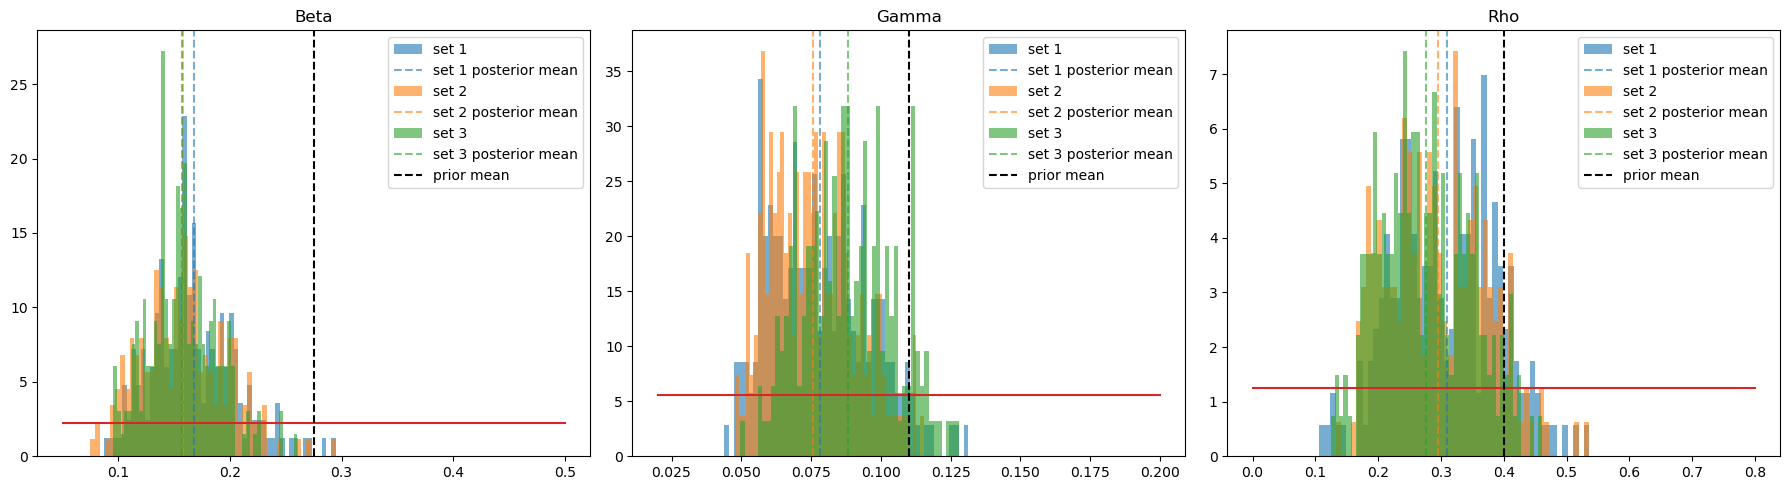

In [16]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plot_beta_across_summary([beta_test1_5, beta_test2_5, beta_test3_5])
plt.title("Beta")

plt.subplot(1, 3, 2)
plot_gamma_across_summary([gamma_test1_5, gamma_test2_5, gamma_test3_5])
plt.title("Gamma")

plt.subplot(1, 3, 3)
plot_rho_across_summary([rho_test1_5, rho_test2_5, rho_test3_5])
plt.title("Rho")

plt.tight_layout()
plt.show()

Set 4:

In [17]:
def set_5_summary_obs(obs_infected, obs_rewiring, obs_degree):

    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_growth = obs_infected[1]/obs_infected[0]
    initial_slope = obs_infected[5]-obs_infected[0]

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    time_from_peak_to_end = duration - time_to_peak_infected
    
    # normalization
    peak_infected_norm = (peak_infected - peak_infected_mean) /peak_infected_std
    time_to_peak_infected_norm = (time_to_peak_infected - time_to_peak_infected_mean)/ time_to_peak_infected_std
    total_Infected_norm = (total_Infected - total_Infected_mean) / total_Infected_std
    initial_growth_norm = (initial_growth - initial_growth_mean) / initial_growth_std
    initial_slope_norm = (initial_slope - initial_slope_mean)/ initial_slope_std
        
    total_rewire_norm = (total_rewire - total_rewire_mean) / total_rewire_std
    peak_rewire_norm = (peak_rewire - peak_rewire_mean) / peak_rewire_std
    time_to_peak_rewire_norm =  (time_to_peak_rewire - time_to_peak_rewire_mean) / time_to_peak_rewire_std
    mean_final_degree_norm = (mean_final_degree -mean_final_degree_mean)  / mean_final_degree_std
    var_final_degree_norm = (var_final_degree - var_final_degree_mean) / var_final_degree_std
    ratio_norm  = (ratio - ratio_mean) / ratio_std
    
    width_at_half_peak_norm = ( width_at_half_peak - width_at_half_peak_mean) / width_at_half_peak_std 
    duration_norm = (duration - duration_mean) / duration_std
    time_from_peak_to_end_norm = (time_from_peak_to_end - time_from_peak_to_end_mean) / time_from_peak_to_end_std

    return peak_infected_norm, time_to_peak_infected_norm , peak_rewire_norm, ratio_norm, width_at_half_peak_norm, mean_final_degree_norm



def set_5_summary_sim(sim_infected, sim_rewiring, sim_degree):

    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_growth2 = sim_infected.T[1]/sim_infected.T[0]
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis = 1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    time_from_peak_to_end2 = duration2 - time_to_peak_infected2
    
    peak_infected_norm2 = (peak_infected2 - peak_infected_mean) /peak_infected_std
    time_to_peak_infected_norm2 = (time_to_peak_infected2 - time_to_peak_infected_mean)/ time_to_peak_infected_std
    total_Infected_norm2 = (total_Infected2 - total_Infected_mean) / total_Infected_std
    initial_growth_norm2 = (initial_growth2 - initial_growth_mean) / initial_growth_std
    initial_slope_norm2 = (initial_slope2 - initial_slope_mean)/ initial_slope_std
        
    total_rewire_norm2 = (total_rewire2 - total_rewire_mean) / total_rewire_std
    peak_rewire_norm2 = (peak_rewire2 - peak_rewire_mean) / peak_rewire_std
    time_to_peak_rewire_norm2 =  (time_to_peak_rewire2 - time_to_peak_rewire_mean) / time_to_peak_rewire_std
    mean_final_degree_norm2 = (mean_final_degree2 -mean_final_degree_mean)  / mean_final_degree_std
    var_final_degree_norm2 = (var_final_degree2 - var_final_degree_mean) / var_final_degree_std
    ratio_norm2  = (ratio2 - ratio_mean) / ratio_std
    
    width_at_half_peak_norm2 = ( width_at_half_peak2 - width_at_half_peak_mean) / width_at_half_peak_std 
    duration_norm2 = (duration2 - duration_mean) / duration_std
    time_from_peak_to_end_norm2 = (time_from_peak_to_end2 - time_from_peak_to_end_mean) / time_from_peak_to_end_std
    
    return peak_infected_norm2,time_to_peak_infected_norm2 , peak_rewire_norm2, ratio_norm2, width_at_half_peak_norm2, mean_final_degree_norm2

In [18]:
summary_test5_train = set_5_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test5_sim = set_5_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test5_test = set_5_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test5_sim = np.array(summary_test5_sim).T
summary_test5_train = np.array(summary_test5_train)
summary_test5_test = np.array(summary_test5_test)

distance = np.linalg.norm(summary_test5_train - summary_test5_sim, axis = 1)

indices_test5_5, beta_test52_5, gamma_test52_5, rho_test52_5  = accept_indices(distance, acceptance_rate )


posterior_test5_infected, posterior_test5_rewiring, posterior_test5_degree = test_on_summary(indices_test5_5, 50)

summary_test5_post= set_5_summary_sim(posterior_test5_infected, posterior_test5_rewiring, posterior_test5_degree)
summary_test5_post = np.array(summary_test5_post).T


error = np.mean(np.linalg.norm(summary_test5_test - summary_test5_post, axis = 1)**2  )
print(error)
print(np.std(beta_test52_5))
print(np.std(gamma_test52_5))
print(np.std(rho_test52_5))

0.5338312910955311
0.03168566169420324
0.01671576017435852
0.06868658928411975


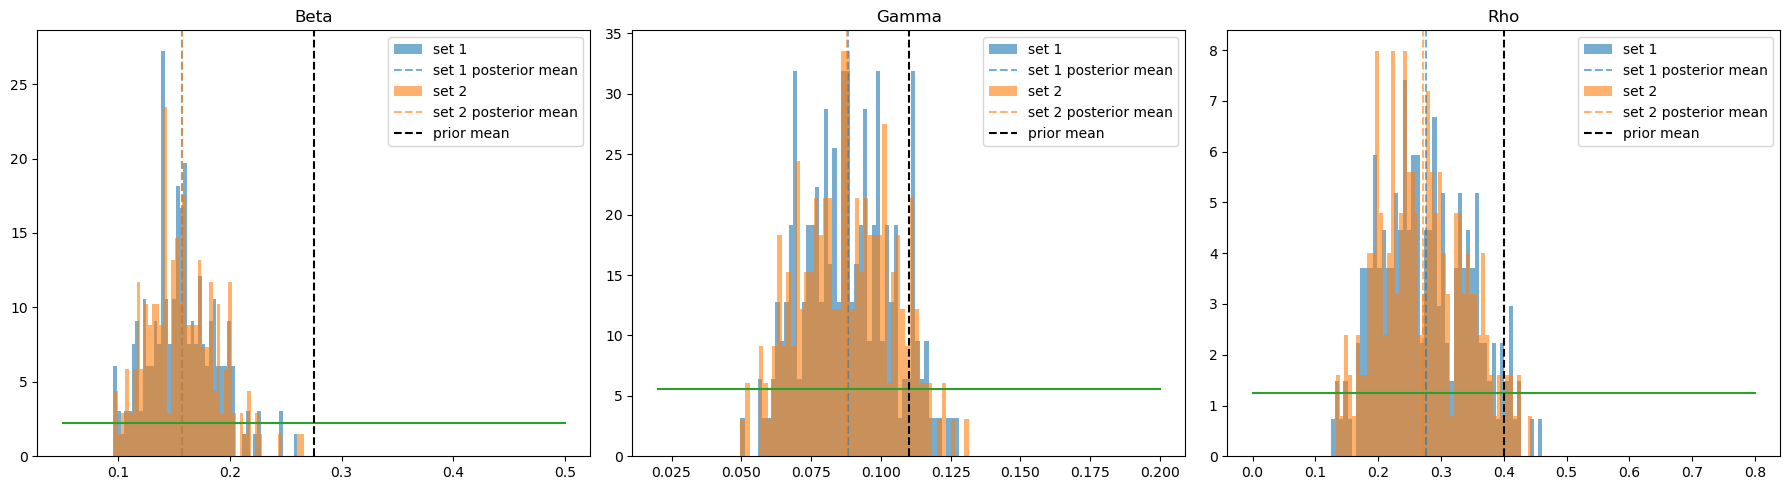

In [19]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plot_beta_across_summary([beta_test3_5, beta_test52_5])
plt.title("Beta")

plt.subplot(1, 3, 2)
plot_gamma_across_summary([gamma_test3_5, gamma_test52_5])
plt.title("Gamma")

plt.subplot(1, 3, 3)
plot_rho_across_summary([rho_test3_5,rho_test52_5])
plt.title("Rho")

plt.tight_layout()
plt.show()

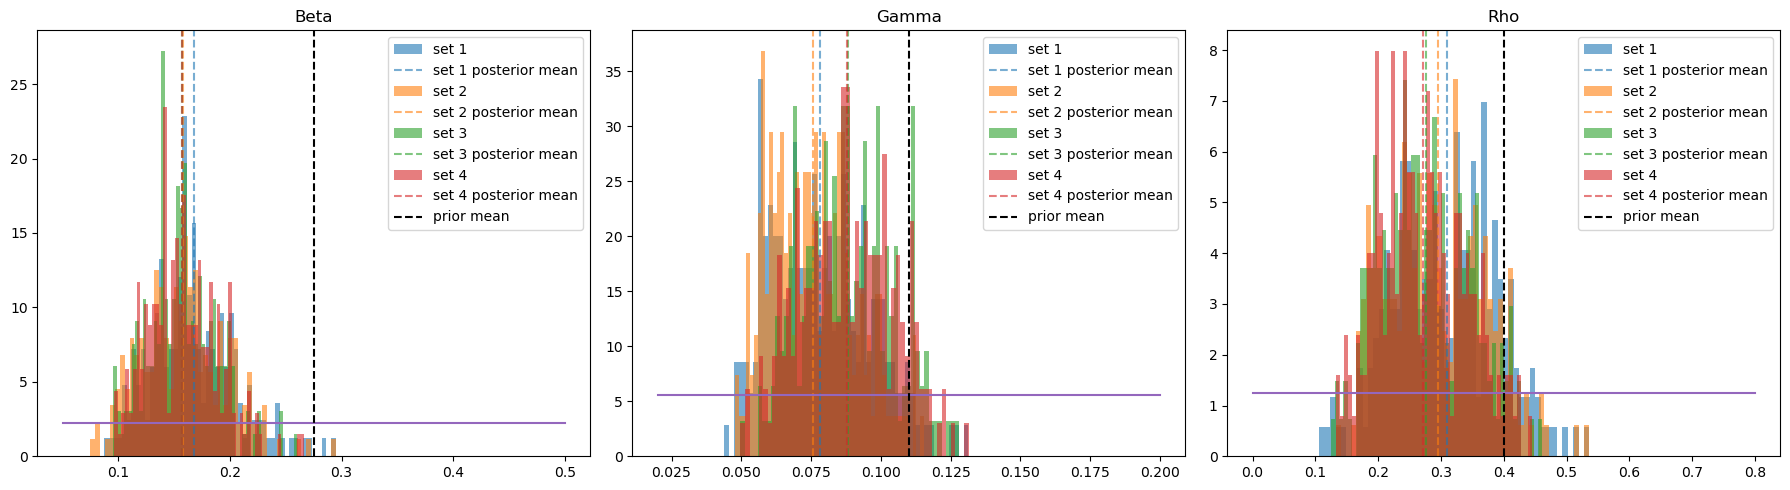

In [20]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plot_beta_across_summary([beta_test1_5, beta_test2_5, beta_test3_5, beta_test52_5])
plt.title("Beta")

plt.subplot(1, 3, 2)
plot_gamma_across_summary([gamma_test1_5, gamma_test2_5, gamma_test3_5, gamma_test52_5])
plt.title("Gamma")

plt.subplot(1, 3, 3)
plot_rho_across_summary([rho_test1_5, rho_test2_5, rho_test3_5, rho_test52_5])
plt.title("Rho")

plt.tight_layout()
plt.show()

# Below are reference

# Reference

### test4:

[
    peak_infected,
    time_to_peak_infected,
    total_Infected,
    duration,
    total_rewire,
    time_to_peak_rewire,
    correlation,
    ratio
]

In [629]:
def set_4_summary_obs(obs_infected, obs_rewiring, obs_degree):      
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_slope = obs_infected[5]-obs_infected[0]

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    
    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std
    initial_slope_norm = initial_slope/ initial_slope_std
        
    total_rewire_norm = total_rewire / total_rewire_std
    peak_rewire_norm = peak_rewire / peak_rewire_std
    time_to_peak_rewire_norm =  time_to_peak_rewire / time_to_peak_rewire_std
    mean_final_degree_norm = mean_final_degree / mean_final_degree_std
    ratio_norm  = ratio / ratio_std
    
    width_at_half_peak_norm = width_at_half_peak / width_at_half_peak_std 
    duration_norm = duration/ duration_std
    
    return peak_infected_norm, time_to_peak_infected_norm, total_Infected_norm, total_rewire_norm, ratio_norm, duration_norm, time_to_peak_rewire_norm



def set_4_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    
    peak_infected_norm2 = peak_infected2 /peak_infected_std
    time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std
    initial_slope_norm2 = initial_slope2/ initial_slope_std
        
    total_rewire_norm2 = total_rewire2 / total_rewire_std
    peak_rewire_norm2 = peak_rewire2 / peak_rewire_std
    time_to_peak_rewire_norm2 =  time_to_peak_rewire2 / time_to_peak_rewire_std
    mean_final_degree_norm2 = mean_final_degree2 / mean_final_degree_std
    ratio_norm2  = ratio2 / ratio_std
    
    width_at_half_peak_norm2 = width_at_half_peak2 / width_at_half_peak_std 
    duration_norm2 = duration2/ duration_std
    
    return peak_infected_norm2, time_to_peak_infected_norm2, total_Infected_norm2, total_rewire_norm2, ratio_norm2, duration_norm2, time_to_peak_rewire_norm2


In [630]:
summary_test4_train = set_4_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test4_sim = set_4_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test4_test = set_4_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test4_sim = np.array(summary_test4_sim).T
summary_test4_train = np.array(summary_test4_train)
summary_test4_test = np.array(summary_test4_test)

In [631]:
distance = np.linalg.norm(summary_test4_train - summary_test4_sim, axis = 1)      

# 5% acceptance rate:                                                   
indices_test4_5, beta_test4_5, gamma_test4_5, rho_test4_5  = accept_indices(distance, 0.05)

In [632]:
# test
posterior_test4_indices = rng.choice(indices_test4_5, size = 50, replace = False)

beta_test4_posterior = beta_list[posterior_test4_indices]
gamma_test4_posterior = gamma_list[posterior_test4_indices]
rho_test4_posterior = rho_list[posterior_test4_indices]

posterior_test4_infected = []
posterior_test4_rewiring = []
posterior_test4_degree = []

for i in range(50):
    beta_posterior = beta_test4_posterior[i]
    gamma_posterior = gamma_test4_posterior[i]
    rho_posterior = rho_test4_posterior[i]
    
    infected, rewires, degrees = simulate(beta = beta_posterior, gamma = gamma_posterior, rho = rho_posterior, rng = rng)
    
    posterior_test4_infected.append(infected)
    posterior_test4_rewiring.append(rewires)
    posterior_test4_degree.append(degrees)

posterior_test4_infected = np.array(posterior_test4_infected)
posterior_test4_rewiring = np.array(posterior_test4_rewiring)
posterior_test4_degree = np.array(posterior_test4_degree)

summary_test4_post= set_4_summary_sim(posterior_test4_infected, posterior_test4_rewiring, posterior_test4_degree)
summary_test4_post = np.array(summary_test4_post).T


error = np.mean(np.linalg.norm(summary_test4_test - summary_test4_post, axis = 1)**2  )
print(error)
print(np.std(beta_test4_5))
print(np.std(gamma_test4_5))
print(np.std(rho_test4_5))

1.7822602957475246
0.08749066195635713
0.017934718744976718
0.14271660976042944


test3:                             ---> not in colab
(if beta hard to infer)  

[
    peak_infected,
    total_Infected,
    duration,
    initial_growth,
    initial_slope,
    total_rewire,
    correlation,
    ratio
]

In [633]:
def set_4_summary_obs(obs_infected, obs_rewiring, obs_degree):      
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_slope = obs_infected[5]-obs_infected[0]

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)
    correlation = np.corrcoef(obs_infected, obs_rewiring)[0,1]

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    
    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std
    initial_slope_norm = initial_slope/ initial_slope_std
        
    total_rewire_norm = total_rewire / total_rewire_std
    peak_rewire_norm = peak_rewire / peak_rewire_std
    time_to_peak_rewire_norm =  time_to_peak_rewire / time_to_peak_rewire_std
    mean_final_degree_norm = mean_final_degree / mean_final_degree_std
    ratio_norm  = ratio / ratio_std
    correlation_norm = correlation/correlation_std
    
    
    width_at_half_peak_norm = width_at_half_peak / width_at_half_peak_std 
    duration_norm = duration/ duration_std
    var_final_degree_norm = var_final_degree/var_final_degree_std
    
    return peak_infected_norm, total_Infected_norm, initial_slope_norm, total_rewire_norm, ratio_norm, duration_norm, mean_final_degree_norm, time_to_peak_rewire_norm



def set_4_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis =1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    cov = np.mean(( sim_infected- np.mean(sim_infected, axis=1, keepdims=True)) * (sim_rewiring - np.mean(sim_rewiring, axis = 1,keepdims=True)), axis=1)
    denom = sim_infected.std(axis=1) * sim_rewiring.std(axis=1)
    correlation2 = np.zeros_like(denom)
    valid = denom > 0
    correlation2[valid] = cov[valid] / denom[valid]
    
    peak_infected_norm2 = peak_infected2 /peak_infected_std
    time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std
    initial_slope_norm2 = initial_slope2/ initial_slope_std
    var_final_degree_norm2 = var_final_degree2/var_final_degree_std
    total_rewire_norm2 = total_rewire2 / total_rewire_std
    peak_rewire_norm2 = peak_rewire2 / peak_rewire_std
    time_to_peak_rewire_norm2 =  time_to_peak_rewire2 / time_to_peak_rewire_std
    mean_final_degree_norm2 = mean_final_degree2 / mean_final_degree_std
    ratio_norm2  = ratio2 / ratio_std
    correlation_norm2 = correlation2 / correlation_std
    
    width_at_half_peak_norm2 = width_at_half_peak2 / width_at_half_peak_std 
    duration_norm2 = duration2/ duration_std
    
    return peak_infected_norm2, total_Infected_norm2, initial_slope_norm2, total_rewire_norm2, ratio_norm2, duration_norm2, mean_final_degree_norm2, time_to_peak_rewire_norm2

In [634]:
summary_test4_train = set_4_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test4_sim = set_4_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test4_test = set_4_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test4_sim = np.array(summary_test4_sim).T
summary_test4_train = np.array(summary_test4_train)
summary_test4_test = np.array(summary_test4_test)

In [635]:
distance = np.linalg.norm(summary_test4_train - summary_test4_sim, axis = 1)      

# 5% acceptance rate:                                                   
indices_test4_5, beta_test4_5, gamma_test4_5, rho_test4_5  = accept_indices(distance, 0.05)

In [636]:
# test
posterior_test4_indices = rng.choice(indices_test4_5, size = 50, replace = False)

beta_test4_posterior = beta_list[posterior_test4_indices]
gamma_test4_posterior = gamma_list[posterior_test4_indices]
rho_test4_posterior = rho_list[posterior_test4_indices]

posterior_test4_infected = []
posterior_test4_rewiring = []
posterior_test4_degree = []

for i in range(50):
    beta_posterior = beta_test4_posterior[i]
    gamma_posterior = gamma_test4_posterior[i]
    rho_posterior = rho_test4_posterior[i]
    
    infected, rewires, degrees = simulate(beta = beta_posterior, gamma = gamma_posterior, rho = rho_posterior, rng = rng)
    
    posterior_test4_infected.append(infected)
    posterior_test4_rewiring.append(rewires)
    posterior_test4_degree.append(degrees)

posterior_test4_infected = np.array(posterior_test4_infected)
posterior_test4_rewiring = np.array(posterior_test4_rewiring)
posterior_test4_degree = np.array(posterior_test4_degree)

summary_test4_post= set_4_summary_sim(posterior_test4_infected, posterior_test4_rewiring, posterior_test4_degree)
summary_test4_post = np.array(summary_test4_post).T


error = np.mean(np.linalg.norm(summary_test4_test - summary_test4_post, axis = 1)**2  )
print(error)
print(np.std(beta_test4_5))
print(np.std(gamma_test4_5))
print(np.std(rho_test4_5))

2.2099654127524238
0.07154527938905589
0.022109073106805613
0.1549314330492486


[
    peak_infected,
    time_to_peak_infected,
    total_Infected,

    duration,                # γ (light addition)

    total_rewire,
    ratio
]

In [544]:
def set_4_summary_obs(obs_infected, obs_rewiring, obs_degree):      
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_slope = obs_infected[5]-obs_infected[0]

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    
    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std
    initial_slope_norm = initial_slope/ initial_slope_std
        
    total_rewire_norm = total_rewire / total_rewire_std
    peak_rewire_norm = peak_rewire / peak_rewire_std
    time_to_peak_rewire_norm =  time_to_peak_rewire / time_to_peak_rewire_std
    mean_final_degree_norm = mean_final_degree / mean_final_degree_std
    ratio_norm  = ratio / ratio_std
    
    width_at_half_peak_norm = width_at_half_peak / width_at_half_peak_std 
    duration_norm = duration/ duration_std
    var_final_degree_norm = var_final_degree/var_final_degree_std
    
    return peak_infected_norm, time_to_peak_infected_norm, total_Infected_norm, duration_norm, total_rewire_norm, ratio_norm



def set_4_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis =1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    
    peak_infected_norm2 = peak_infected2 /peak_infected_std
    time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std
    initial_slope_norm2 = initial_slope2/ initial_slope_std
    var_final_degree_norm2 = var_final_degree2/var_final_degree_std
    total_rewire_norm2 = total_rewire2 / total_rewire_std
    peak_rewire_norm2 = peak_rewire2 / peak_rewire_std
    time_to_peak_rewire_norm2 =  time_to_peak_rewire2 / time_to_peak_rewire_std
    mean_final_degree_norm2 = mean_final_degree2 / mean_final_degree_std
    ratio_norm2  = ratio2 / ratio_std
    
    width_at_half_peak_norm2 = width_at_half_peak2 / width_at_half_peak_std 
    duration_norm2 = duration2/ duration_std
    
    return peak_infected_norm2, time_to_peak_infected_norm2, total_Infected_norm2, duration_norm2, total_rewire_norm2, ratio_norm2

In [545]:
summary_test4_train = set_4_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test4_sim = set_4_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test4_test = set_4_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test4_sim = np.array(summary_test4_sim).T
summary_test4_train = np.array(summary_test4_train)
summary_test4_test = np.array(summary_test4_test)

In [546]:
distance = np.linalg.norm(summary_test4_train - summary_test4_sim, axis = 1)      

# 5% acceptance rate:                                                   
indices_test4_5, beta_test4_5, gamma_test4_5, rho_test4_5  = accept_indices(distance, 0.05)

In [547]:
# test
posterior_test4_indices = rng.choice(indices_test4_5, size = 50, replace = False)

beta_test4_posterior = beta_list[posterior_test4_indices]
gamma_test4_posterior = gamma_list[posterior_test4_indices]
rho_test4_posterior = rho_list[posterior_test4_indices]

posterior_test4_infected = []
posterior_test4_rewiring = []
posterior_test4_degree = []

for i in range(50):
    beta_posterior = beta_test4_posterior[i]
    gamma_posterior = gamma_test4_posterior[i]
    rho_posterior = rho_test4_posterior[i]
    
    infected, rewires, degrees = simulate(beta = beta_posterior, gamma = gamma_posterior, rho = rho_posterior, rng = rng)
    
    posterior_test4_infected.append(infected)
    posterior_test4_rewiring.append(rewires)
    posterior_test4_degree.append(degrees)

posterior_test4_infected = np.array(posterior_test4_infected)
posterior_test4_rewiring = np.array(posterior_test4_rewiring)
posterior_test4_degree = np.array(posterior_test4_degree)

summary_test4_post= set_4_summary_sim(posterior_test4_infected, posterior_test4_rewiring, posterior_test4_degree)
summary_test4_post = np.array(summary_test4_post).T


error = np.mean(np.linalg.norm(summary_test4_test - summary_test4_post, axis = 1)**2  )
print(error)
print(np.std(beta_test4_5))
print(np.std(gamma_test4_5))
print(np.std(rho_test4_5))

1.527948419676867
0.09408258792799175
0.017260986305481032
0.1411486656000599


[
    peak_infected,
    time_to_peak_infected,
    total_Infected,

    duration,
    time_from_peak_to_end,   # ← KEY improvement

    total_rewire,
    ratio
]

In [550]:
def set_4_summary_obs(obs_infected, obs_rewiring, obs_degree):      
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_slope = obs_infected[5]-obs_infected[0]
    

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    time_from_peak_to_end = duration - time_to_peak_infected
    
    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std
    initial_slope_norm = initial_slope/ initial_slope_std
    time_from_peak_to_end_norm = time_from_peak_to_end / time_from_peak_to_end_std
        
    total_rewire_norm = total_rewire / total_rewire_std
    peak_rewire_norm = peak_rewire / peak_rewire_std
    time_to_peak_rewire_norm =  time_to_peak_rewire / time_to_peak_rewire_std
    mean_final_degree_norm = mean_final_degree / mean_final_degree_std
    ratio_norm  = ratio / ratio_std
    
    width_at_half_peak_norm = width_at_half_peak / width_at_half_peak_std 
    duration_norm = duration/ duration_std
    var_final_degree_norm = var_final_degree/var_final_degree_std
    
    return peak_infected_norm, time_to_peak_infected_norm, total_Infected_norm, duration_norm, total_rewire_norm, ratio_norm, time_from_peak_to_end_norm



def set_4_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis =1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    time_from_peak_to_end2 = duration2 - time_to_peak_infected2
    
    peak_infected_norm2 = peak_infected2 /peak_infected_std
    time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std
    initial_slope_norm2 = initial_slope2/ initial_slope_std
    var_final_degree_norm2 = var_final_degree2/var_final_degree_std
    total_rewire_norm2 = total_rewire2 / total_rewire_std
    peak_rewire_norm2 = peak_rewire2 / peak_rewire_std
    time_to_peak_rewire_norm2 =  time_to_peak_rewire2 / time_to_peak_rewire_std
    mean_final_degree_norm2 = mean_final_degree2 / mean_final_degree_std
    ratio_norm2  = ratio2 / ratio_std
    
    time_from_peak_to_end_norm2 = time_from_peak_to_end2/time_from_peak_to_end_std
    width_at_half_peak_norm2 = width_at_half_peak2 / width_at_half_peak_std 
    duration_norm2 = duration2/ duration_std
    
    return peak_infected_norm2, time_to_peak_infected_norm2, total_Infected_norm2, duration_norm2, total_rewire_norm2, ratio_norm2, time_from_peak_to_end_norm2

In [551]:
summary_test4_train = set_4_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test4_sim = set_4_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test4_test = set_4_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test4_sim = np.array(summary_test4_sim).T
summary_test4_train = np.array(summary_test4_train)
summary_test4_test = np.array(summary_test4_test)

In [552]:
distance = np.linalg.norm(summary_test4_train - summary_test4_sim, axis = 1)      

# 5% acceptance rate:                                                   
indices_test4_5, beta_test4_5, gamma_test4_5, rho_test4_5  = accept_indices(distance, 0.05)

In [553]:
# test
posterior_test4_indices = rng.choice(indices_test4_5, size = 50, replace = False)

beta_test4_posterior = beta_list[posterior_test4_indices]
gamma_test4_posterior = gamma_list[posterior_test4_indices]
rho_test4_posterior = rho_list[posterior_test4_indices]

posterior_test4_infected = []
posterior_test4_rewiring = []
posterior_test4_degree = []

for i in range(50):
    beta_posterior = beta_test4_posterior[i]
    gamma_posterior = gamma_test4_posterior[i]
    rho_posterior = rho_test4_posterior[i]
    
    infected, rewires, degrees = simulate(beta = beta_posterior, gamma = gamma_posterior, rho = rho_posterior, rng = rng)
    
    posterior_test4_infected.append(infected)
    posterior_test4_rewiring.append(rewires)
    posterior_test4_degree.append(degrees)

posterior_test4_infected = np.array(posterior_test4_infected)
posterior_test4_rewiring = np.array(posterior_test4_rewiring)
posterior_test4_degree = np.array(posterior_test4_degree)

summary_test4_post= set_4_summary_sim(posterior_test4_infected, posterior_test4_rewiring, posterior_test4_degree)
summary_test4_post = np.array(summary_test4_post).T


error = np.mean(np.linalg.norm(summary_test4_test - summary_test4_post, axis = 1)**2  )
print(error)
print(np.std(beta_test4_5))
print(np.std(gamma_test4_5))
print(np.std(rho_test4_5))

2.1063920414920294
0.10124446678403322
0.016083001403580845
0.15301990594784035


[
    peak_infected,
    time_to_peak_infected,
    total_Infected,

    duration,

    total_rewire,
    correlation,   # ← NEW (replace noisy timing)
    ratio
]

In [554]:
def set_4_summary_obs(obs_infected, obs_rewiring, obs_degree):      
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_slope = obs_infected[5]-obs_infected[0]
    

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)
    correlation = np.corrcoef(obs_infected, obs_rewiring)[0,1]

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    time_from_peak_to_end = duration - time_to_peak_infected
    
    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std
    initial_slope_norm = initial_slope/ initial_slope_std
    time_from_peak_to_end_norm = time_from_peak_to_end / time_from_peak_to_end_std
        
    total_rewire_norm = total_rewire / total_rewire_std
    peak_rewire_norm = peak_rewire / peak_rewire_std
    time_to_peak_rewire_norm =  time_to_peak_rewire / time_to_peak_rewire_std
    mean_final_degree_norm = mean_final_degree / mean_final_degree_std
    ratio_norm  = ratio / ratio_std
    correlation_norm = correlation/ correlation_std
    
    width_at_half_peak_norm = width_at_half_peak / width_at_half_peak_std 
    duration_norm = duration/ duration_std
    var_final_degree_norm = var_final_degree/var_final_degree_std
    
    return peak_infected_norm, time_to_peak_infected_norm, total_Infected_norm, duration_norm, total_rewire_norm, ratio_norm, correlation_norm



def set_4_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis =1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    time_from_peak_to_end2 = duration2 - time_to_peak_infected2
    cov = np.mean(( sim_infected- np.mean(sim_infected, axis=1, keepdims=True)) * (sim_rewiring - np.mean(sim_rewiring, axis = 1,keepdims=True)), axis=1)
    denom = sim_infected.std(axis=1) * sim_rewiring.std(axis=1)
    correlation2 = np.zeros_like(denom)
    valid = denom > 0
    correlation2[valid] = cov[valid] / denom[valid]
    
    peak_infected_norm2 = peak_infected2 /peak_infected_std
    time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std
    initial_slope_norm2 = initial_slope2/ initial_slope_std
    var_final_degree_norm2 = var_final_degree2/var_final_degree_std
    total_rewire_norm2 = total_rewire2 / total_rewire_std
    peak_rewire_norm2 = peak_rewire2 / peak_rewire_std
    time_to_peak_rewire_norm2 =  time_to_peak_rewire2 / time_to_peak_rewire_std
    mean_final_degree_norm2 = mean_final_degree2 / mean_final_degree_std
    ratio_norm2  = ratio2 / ratio_std
    
    time_from_peak_to_end_norm2 = time_from_peak_to_end2/time_from_peak_to_end_std
    width_at_half_peak_norm2 = width_at_half_peak2 / width_at_half_peak_std 
    duration_norm2 = duration2/ duration_std
    correlation_norm2 = correlation2/correlation_std
    
    return peak_infected_norm2, time_to_peak_infected_norm2, total_Infected_norm2, duration_norm2, total_rewire_norm2, ratio_norm2, correlation_norm2

In [555]:
summary_test4_train = set_4_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test4_sim = set_4_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test4_test = set_4_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test4_sim = np.array(summary_test4_sim).T
summary_test4_train = np.array(summary_test4_train)
summary_test4_test = np.array(summary_test4_test)

In [556]:
distance = np.linalg.norm(summary_test4_train - summary_test4_sim, axis = 1)      

# 5% acceptance rate:                                                   
indices_test4_5, beta_test4_5, gamma_test4_5, rho_test4_5  = accept_indices(distance, 0.05)

In [557]:
# test
posterior_test4_indices = rng.choice(indices_test4_5, size = 50, replace = False)

beta_test4_posterior = beta_list[posterior_test4_indices]
gamma_test4_posterior = gamma_list[posterior_test4_indices]
rho_test4_posterior = rho_list[posterior_test4_indices]

posterior_test4_infected = []
posterior_test4_rewiring = []
posterior_test4_degree = []

for i in range(50):
    beta_posterior = beta_test4_posterior[i]
    gamma_posterior = gamma_test4_posterior[i]
    rho_posterior = rho_test4_posterior[i]
    
    infected, rewires, degrees = simulate(beta = beta_posterior, gamma = gamma_posterior, rho = rho_posterior, rng = rng)
    
    posterior_test4_infected.append(infected)
    posterior_test4_rewiring.append(rewires)
    posterior_test4_degree.append(degrees)

posterior_test4_infected = np.array(posterior_test4_infected)
posterior_test4_rewiring = np.array(posterior_test4_rewiring)
posterior_test4_degree = np.array(posterior_test4_degree)

summary_test4_post= set_4_summary_sim(posterior_test4_infected, posterior_test4_rewiring, posterior_test4_degree)
summary_test4_post = np.array(summary_test4_post).T


error = np.mean(np.linalg.norm(summary_test4_test - summary_test4_post, axis = 1)**2  )
print(error)
print(np.std(beta_test4_5))
print(np.std(gamma_test4_5))
print(np.std(rho_test4_5))

1.9834974075790917
0.08574188433734274
0.019183257029458955
0.14579504043558633


[
    peak_infected,
    time_to_peak_infected,
    total_Infected,

    duration,
    time_from_peak_to_end,

    total_rewire,
    correlation,
    ratio
]

In [558]:
def set_4_summary_obs(obs_infected, obs_rewiring, obs_degree):      
    
    # beta:
    peak_infected = np.max(obs_infected)
    time_to_peak_infected = np.argmax(obs_infected)
    total_Infected = np.sum(obs_infected)                            # AUC
    initial_slope = obs_infected[5]-obs_infected[0]
    

    # rho:
    total_rewire = np.sum(obs_rewiring)
    peak_rewire = np.max(obs_rewiring)
    time_to_peak_rewire = np.argmax(obs_rewiring)
    ratio = np.sum(obs_rewiring)/np.sum(obs_infected)
    mean_final_degree = np.mean(obs_degree)
    var_final_degree = np.var(obs_degree)
    correlation = np.corrcoef(obs_infected, obs_rewiring)[0,1]

    # gamma:
    width_at_half_peak = np.sum(obs_infected > np.max(obs_infected)/2)
    duration = np.sum(obs_infected > 1e-6)
    time_from_peak_to_end = duration - time_to_peak_infected
    
    # normalization
    peak_infected_norm = peak_infected /peak_infected_std
    time_to_peak_infected_norm = time_to_peak_infected/ time_to_peak_infected_std
    total_Infected_norm = total_Infected / total_Infected_std
    initial_slope_norm = initial_slope/ initial_slope_std
    time_from_peak_to_end_norm = time_from_peak_to_end / time_from_peak_to_end_std
        
    total_rewire_norm = total_rewire / total_rewire_std
    peak_rewire_norm = peak_rewire / peak_rewire_std
    time_to_peak_rewire_norm =  time_to_peak_rewire / time_to_peak_rewire_std
    mean_final_degree_norm = mean_final_degree / mean_final_degree_std
    ratio_norm  = ratio / ratio_std
    correlation_norm = correlation/ correlation_std
    
    width_at_half_peak_norm = width_at_half_peak / width_at_half_peak_std 
    duration_norm = duration/ duration_std
    var_final_degree_norm = var_final_degree/var_final_degree_std
    
    return peak_infected_norm, time_to_peak_infected_norm, total_Infected_norm, duration_norm, time_from_peak_to_end_norm, total_rewire_norm, ratio_norm, correlation_norm



def set_4_summary_sim(sim_infected, sim_rewiring, sim_degree):
      
    peak_infected2 = np.max(sim_infected, axis = 1)
    time_to_peak_infected2 = np.argmax(sim_infected, axis = 1)
    total_Infected2 = np.sum(sim_infected, axis=1)                            
    initial_slope2 = sim_infected.T[5]-sim_infected.T[0]
        
    total_rewire2 = np.sum(sim_rewiring, axis = 1)
    peak_rewire2 = np.max(sim_rewiring, axis = 1)
    time_to_peak_rewire2 = np.argmax(sim_rewiring, axis=1)

    mean_final_degree2 = np.mean(sim_degree, axis =1)
    var_final_degree2 = np.var(sim_degree, axis =1)
    ratio2 = np.sum(sim_rewiring, axis = 1)/np.sum(sim_infected, axis = 1)

    width_at_half_peak2 = np.sum(sim_infected > np.max(sim_infected, keepdims=True, axis = 1)/2, axis = 1)
    duration2 = np.sum(sim_infected > 1e-6, axis = 1)
    time_from_peak_to_end2 = duration2 - time_to_peak_infected2
    cov = np.mean(( sim_infected- np.mean(sim_infected, axis=1, keepdims=True)) * (sim_rewiring - np.mean(sim_rewiring, axis = 1,keepdims=True)), axis=1)
    denom = sim_infected.std(axis=1) * sim_rewiring.std(axis=1)
    correlation2 = np.zeros_like(denom)
    valid = denom > 0
    correlation2[valid] = cov[valid] / denom[valid]
    
    peak_infected_norm2 = peak_infected2 /peak_infected_std
    time_to_peak_infected_norm2 = time_to_peak_infected2/ time_to_peak_infected_std
    total_Infected_norm2 = total_Infected2 / total_Infected_std
    initial_slope_norm2 = initial_slope2/ initial_slope_std
    var_final_degree_norm2 = var_final_degree2/var_final_degree_std
    total_rewire_norm2 = total_rewire2 / total_rewire_std
    peak_rewire_norm2 = peak_rewire2 / peak_rewire_std
    time_to_peak_rewire_norm2 =  time_to_peak_rewire2 / time_to_peak_rewire_std
    mean_final_degree_norm2 = mean_final_degree2 / mean_final_degree_std
    ratio_norm2  = ratio2 / ratio_std
    
    time_from_peak_to_end_norm2 = time_from_peak_to_end2/time_from_peak_to_end_std
    width_at_half_peak_norm2 = width_at_half_peak2 / width_at_half_peak_std 
    duration_norm2 = duration2/ duration_std
    correlation_norm2 = correlation2/correlation_std
    
    return peak_infected_norm2, time_to_peak_infected_norm2, total_Infected_norm2, duration_norm2, time_from_peak_to_end_norm2, total_rewire_norm2, ratio_norm2, correlation_norm2

In [559]:
summary_test4_train = set_4_summary_obs(obs_infected, obs_rewiring, obs_degree)
summary_test4_sim = set_4_summary_sim(sim_infected, sim_rewiring, sim_degree)
summary_test4_test = set_4_summary_obs(test_obs_infected, test_obs_rewiring, test_obs_degree)

summary_test4_sim = np.array(summary_test4_sim).T
summary_test4_train = np.array(summary_test4_train)
summary_test4_test = np.array(summary_test4_test)

In [560]:
distance = np.linalg.norm(summary_test4_train - summary_test4_sim, axis = 1)      

# 5% acceptance rate:                                                   
indices_test4_5, beta_test4_5, gamma_test4_5, rho_test4_5  = accept_indices(distance, 0.05)

In [561]:
# test
posterior_test4_indices = rng.choice(indices_test4_5, size = 50, replace = False)

beta_test4_posterior = beta_list[posterior_test4_indices]
gamma_test4_posterior = gamma_list[posterior_test4_indices]
rho_test4_posterior = rho_list[posterior_test4_indices]

posterior_test4_infected = []
posterior_test4_rewiring = []
posterior_test4_degree = []

for i in range(50):
    beta_posterior = beta_test4_posterior[i]
    gamma_posterior = gamma_test4_posterior[i]
    rho_posterior = rho_test4_posterior[i]
    
    infected, rewires, degrees = simulate(beta = beta_posterior, gamma = gamma_posterior, rho = rho_posterior, rng = rng)
    
    posterior_test4_infected.append(infected)
    posterior_test4_rewiring.append(rewires)
    posterior_test4_degree.append(degrees)

posterior_test4_infected = np.array(posterior_test4_infected)
posterior_test4_rewiring = np.array(posterior_test4_rewiring)
posterior_test4_degree = np.array(posterior_test4_degree)

summary_test4_post= set_4_summary_sim(posterior_test4_infected, posterior_test4_rewiring, posterior_test4_degree)
summary_test4_post = np.array(summary_test4_post).T


error = np.mean(np.linalg.norm(summary_test4_test - summary_test4_post, axis = 1)**2  )
print(error)
print(np.std(beta_test4_5))
print(np.std(gamma_test4_5))
print(np.std(rho_test4_5))

2.7332471549533603
0.09338755494598944
0.01797487488280596
0.1606026652582035


# Reference

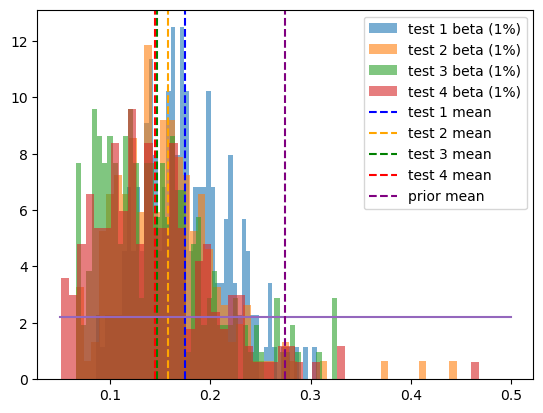

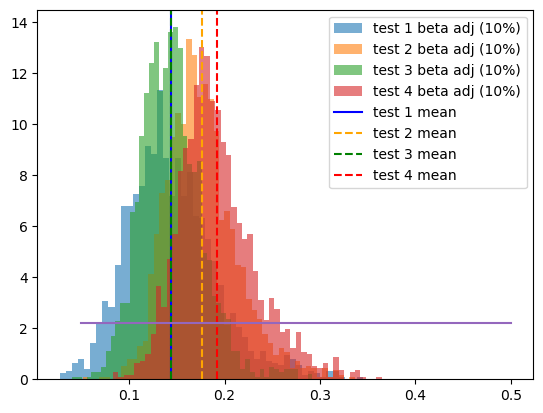

In [80]:
# beta: 1%
plt.figure()
plt.hist(beta_accepted, density = True, bins = 50, label = "test 1 beta (1%)", alpha = 0.6) 
plt.hist(beta_accepted3, density = True, bins = 50, label = "test 2 beta (1%)", alpha = 0.6) 
plt.hist(beta_accepted5, density = True, bins = 50, label = "test 3 beta (1%)", alpha = 0.6) 
plt.hist(beta_accepted7, density = True, bins = 50, label = "test 4 beta (1%)", alpha = 0.6) 
plt.axvline(x = np.mean(beta_accepted),  linestyle = '--', label = 'test 1 mean', color = 'blue')
plt.axvline(x = np.mean(beta_accepted3),  linestyle = '--', label = 'test 2 mean', color = 'orange')
plt.axvline(x = np.mean(beta_accepted5),  linestyle = '--', label = 'test 3 mean', color = 'green')
plt.axvline(x = np.mean(beta_accepted7),  linestyle = '--', label = 'test 4 mean', color = 'red')
x_axis_beta = np.linspace(0.05, 0.5, 100)
y_axis_beta = np.ones(100) * (1/0.45)
plt.plot(x_axis_beta, y_axis_beta)
plt.axvline(x = 0.55/2,  linestyle = '--', label = 'prior mean', color = 'purple')
plt.legend()

# beta: 10% adj
plt.figure()
plt.hist(beta_accepted2_adj, density = True, bins = 50, label = "test 1 beta adj (10%)", alpha = 0.6) 
plt.hist(beta_accepted4_adj, density = True, bins = 50, label = "test 2 beta adj (10%)", alpha = 0.6) 
plt.hist(beta_accepted6_adj, density = True, bins = 50, label = "test 3 beta adj (10%)", alpha = 0.6) 
plt.hist(beta_accepted8_adj, density = True, bins = 50, label = "test 4 beta adj (10%)", alpha = 0.6) 
plt.axvline(x = np.mean(beta_accepted2_adj),   label = 'test 1 mean', color = 'blue')
plt.axvline(x = np.mean(beta_accepted4_adj),  linestyle = '--', label = 'test 2 mean', color = 'orange')
plt.axvline(x = np.mean(beta_accepted6_adj),  linestyle = '--', label = 'test 3 mean', color = 'green')
plt.axvline(x = np.mean(beta_accepted8_adj),  linestyle = '--', label = 'test 4 mean', color = 'red')
x_axis_beta = np.linspace(0.05, 0.5, 100)
y_axis_beta = np.ones(100) * (1/0.45)
plt.plot(x_axis_beta, y_axis_beta)
plt.legend()


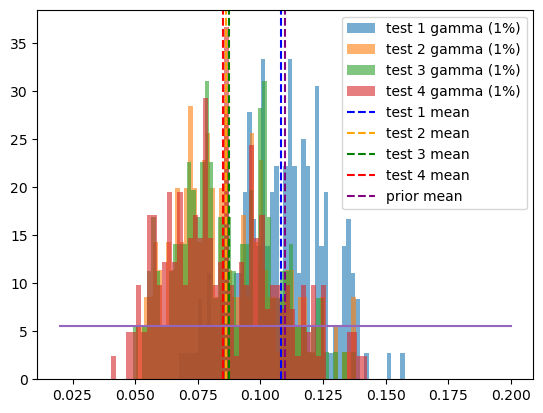

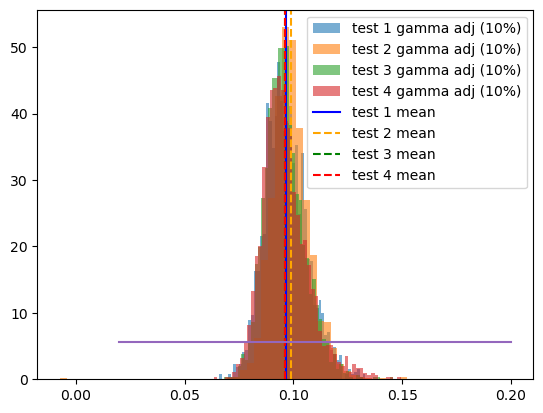

In [81]:
# gamma: 1%
plt.figure()
plt.hist(gamma_accepted, density = True, bins = 50, label = "test 1 gamma (1%)", alpha = 0.6) 
plt.hist(gamma_accepted3, density = True, bins = 50, label = "test 2 gamma (1%)", alpha = 0.6) 
plt.hist(gamma_accepted5, density = True, bins = 50, label = "test 3 gamma (1%)", alpha = 0.6) 
plt.hist(gamma_accepted7, density = True, bins = 50, label = "test 4 gamma (1%)", alpha = 0.6) 
plt.axvline(x = np.mean(gamma_accepted),  linestyle = '--', label = 'test 1 mean', color = 'blue')
plt.axvline(x = np.mean(gamma_accepted3),  linestyle = '--', label = 'test 2 mean', color = 'orange')
plt.axvline(x = np.mean(gamma_accepted5),  linestyle = '--', label = 'test 3 mean', color = 'green')
plt.axvline(x = np.mean(gamma_accepted7),  linestyle = '--', label = 'test 4 mean', color = 'red')
x_axis_gamma = np.linspace(0.02, 0.2, 100)
y_axis_gamma = np.ones(100) * (1/0.18)
plt.plot(x_axis_gamma, y_axis_gamma)
plt.axvline(x = 0.22/2,  linestyle = '--', label = 'prior mean', color = 'purple')
plt.legend()


# gamma: 10% adj
plt.figure()
plt.hist(gamma_accepted2_adj, density = True, bins = 50, label = "test 1 gamma adj (10%)", alpha = 0.6) 
plt.hist(gamma_accepted4_adj, density = True, bins = 50, label = "test 2 gamma adj (10%)", alpha = 0.6) 
plt.hist(gamma_accepted6_adj, density = True, bins = 50, label = "test 3 gamma adj (10%)", alpha = 0.6) 
plt.hist(gamma_accepted8_adj, density = True, bins = 50, label = "test 4 gamma adj (10%)", alpha = 0.6) 
plt.axvline(x = np.mean(gamma_accepted2_adj),   label = 'test 1 mean', color = 'blue')
plt.axvline(x = np.mean(gamma_accepted4_adj),  linestyle = '--', label = 'test 2 mean', color = 'orange')
plt.axvline(x = np.mean(gamma_accepted6_adj),  linestyle = '--', label = 'test 3 mean', color = 'green')
plt.axvline(x = np.mean(gamma_accepted8_adj),  linestyle = '--', label = 'test 4 mean', color = 'red')
x_axis_gamma = np.linspace(0.02, 0.2, 100)
y_axis_gamma = np.ones(100) * (1/0.18)
plt.plot(x_axis_gamma, y_axis_gamma)
plt.legend()


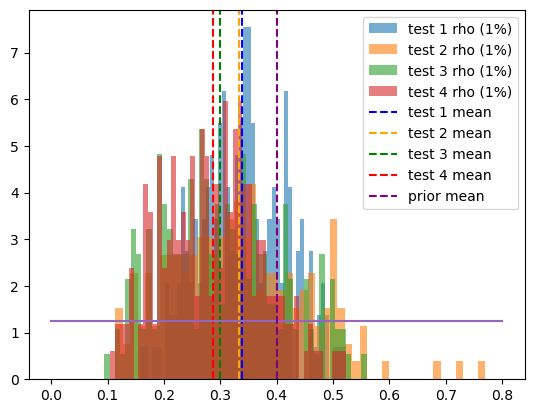

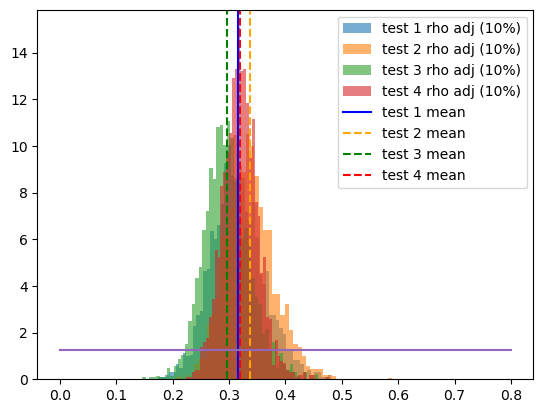

In [82]:
# rho: 1%
plt.figure()
plt.hist(rho_accepted, density = True, bins = 50, label = "test 1 rho (1%)", alpha = 0.6) 
plt.hist(rho_accepted3, density = True, bins = 50, label = "test 2 rho (1%)", alpha = 0.6) 
plt.hist(rho_accepted5, density = True, bins = 50, label = "test 3 rho (1%)", alpha = 0.6) 
plt.hist(rho_accepted7, density = True, bins = 50, label = "test 4 rho (1%)", alpha = 0.6) 
plt.axvline(x = np.mean(rho_accepted),  linestyle = '--', label = 'test 1 mean', color = 'blue')
plt.axvline(x = np.mean(rho_accepted3),  linestyle = '--', label = 'test 2 mean', color = 'orange')
plt.axvline(x = np.mean(rho_accepted5),  linestyle = '--', label = 'test 3 mean', color = 'green')
plt.axvline(x = np.mean(rho_accepted7),  linestyle = '--', label = 'test 4 mean', color = 'red')
x_axis_rho = np.linspace(0, 0.8, 100)
y_axis_rho = np.ones(100) * (1/0.8)
plt.plot(x_axis_rho, y_axis_rho)
plt.axvline(x = 0.8/2,  linestyle = '--', label = 'prior mean', color = 'purple')
plt.legend()

# rho: 10% adj
plt.figure()
plt.hist(rho_accepted2_adj, density = True, bins = 50, label = "test 1 rho adj (10%)", alpha = 0.6) 
plt.hist(rho_accepted4_adj, density = True, bins = 50, label = "test 2 rho adj (10%)", alpha = 0.6) 
plt.hist(rho_accepted6_adj, density = True, bins = 50, label = "test 3 rho adj (10%)", alpha = 0.6) 
plt.hist(rho_accepted8_adj, density = True, bins = 50, label = "test 4 rho adj (10%)", alpha = 0.6) 
plt.axvline(x = np.mean(rho_accepted2_adj),   label = 'test 1 mean', color = 'blue')
plt.axvline(x = np.mean(rho_accepted4_adj),  linestyle = '--', label = 'test 2 mean', color = 'orange')
plt.axvline(x = np.mean(rho_accepted6_adj),  linestyle = '--', label = 'test 3 mean', color = 'green')
plt.axvline(x = np.mean(rho_accepted8_adj),  linestyle = '--', label = 'test 4 mean', color = 'red')
x_axis_rho = np.linspace(0, 0.8, 100)
y_axis_rho = np.ones(100) * (1/0.8)
plt.plot(x_axis_rho, y_axis_rho)
plt.legend()
